In [1]:
import os

dataset_path = r"C:\Users\unnati sutradhar\OneDrive\Desktop\MLProjects\Food Recognition and Calorie Estimation using Deep Learning\archive (12)\UECFOOD100"

if os.path.exists(dataset_path):
    print("✅ Dataset found!")
    print("Contents of the dataset folder:", os.listdir(dataset_path))
else:
    print("❌ Dataset path is incorrect. Please check the folder location.")


✅ Dataset found!
Contents of the dataset folder: ['1', '10', '100', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '9', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', 'category.txt', 'category_ja_euc.txt', 'category_ja_sjis.txt', 'category_ja_utf8.txt', 'multiple_food.txt', 'README.txt']


In [2]:
import os

category_path = os.path.join(dataset_path, "1")  # Path to first category folder
print("Contents of category 1:", os.listdir(category_path))

Contents of category 1: ['1.jpg', '10.jpg', '10572.jpg', '10586.jpg', '10617.jpg', '10618.jpg', '10621.jpg', '10628.jpg', '10630.jpg', '10633.jpg', '10634.jpg', '10640.jpg', '10645.jpg', '10666.jpg', '10740.jpg', '10753.jpg', '10910.jpg', '10993.jpg', '11020.jpg', '11039.jpg', '11059.jpg', '11063.jpg', '11064.jpg', '11094.jpg', '11098.jpg', '11108.jpg', '11119.jpg', '11134.jpg', '11136.jpg', '11138.jpg', '11156.jpg', '11159.jpg', '11161.jpg', '11165.jpg', '11167.jpg', '11180.jpg', '11184.jpg', '11186.jpg', '11194.jpg', '11197.jpg', '11200.jpg', '11201.jpg', '11292.jpg', '11317.jpg', '11326.jpg', '11331.jpg', '11337.jpg', '11352.jpg', '11440.jpg', '11459.jpg', '11568.jpg', '11573.jpg', '11575.jpg', '11576.jpg', '11577.jpg', '11590.jpg', '11593.jpg', '11597.jpg', '11608.jpg', '11649.jpg', '11650.jpg', '11686.jpg', '11689.jpg', '11694.jpg', '11732.jpg', '11737.jpg', '11774.jpg', '11862.jpg', '11956.jpg', '11962.jpg', '11990.jpg', '11997.jpg', '12.jpg', '12079.jpg', '12081.jpg', '12082.jpg

Found 11525 images belonging to 100 classes.
Found 2836 images belonging to 100 classes.


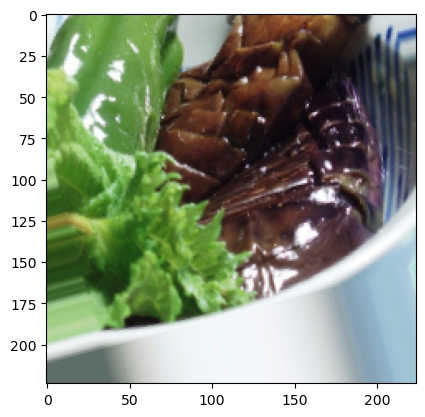

In [3]:
import cv2 #cv2 (OpenCV) → Used for image processing tasks (not directly used here but can be useful for future preprocessing).
import numpy as np #Used for handling arrays efficiently (image data is stored as NumPy arrays).
import matplotlib.pyplot as plt #Used for visualizing images.
from tensorflow.keras.preprocessing.image import ImageDataGenerator #(from keras)Helps with image augmentation and normalization.

IMG_SIZE = 224 # Resizes all images to 224x224 pixels (this is required for deep learning models like EfficientNet, which expect a fixed input size).
BATCH_SIZE = 32  # Number of images processed in one step during training ,  instead of one by one

# Data Augmentation & Normalization
datagen = ImageDataGenerator(
    rescale=1./255,  
    rotation_range=30,  
    width_shift_range=0.2,  
    height_shift_range=0.2,  
    horizontal_flip=True,  
    validation_split=0.2  
)

# Load Training Data
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Load Validation Data
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Show a sample image
img, label = train_data.next()
plt.imshow(img[0])
plt.show()


In [4]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Load Pretrained Model (without top layers)
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the pretrained layers

# Correctly add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Reducing dimensions
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output_layer = Dense(len(train_data.class_indices), activation='softmax')(x)  # Define output separately

# Build and Compile the Model
model = Model(inputs=base_model.input, outputs=output_layer)  # Ensure correct output connection
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the Model
model.fit(train_data, epochs=5, validation_data=val_data)


Epoch 1/5
361/361 [==============================] - 670s 2s/step - loss: 4.5602 - accuracy: 0.0446 - val_loss: 4.5057 - val_accuracy: 0.0511
Epoch 2/5
361/361 [==============================] - 552s 2s/step - loss: 4.5303 - accuracy: 0.0482 - val_loss: 4.5005 - val_accuracy: 0.0511
Epoch 3/5
361/361 [==============================] - 485s 1s/step - loss: 4.5230 - accuracy: 0.0507 - val_loss: 4.5063 - val_accuracy: 0.0511
Epoch 4/5
361/361 [==============================] - 544s 2s/step - loss: 4.5214 - accuracy: 0.0504 - val_loss: 4.4965 - val_accuracy: 0.0511
Epoch 5/5
361/361 [==============================] - 492s 1s/step - loss: 4.5206 - accuracy: 0.0506 - val_loss: 4.4989 - val_accuracy: 0.0511


In [5]:
food_calories = {
    "pizza": 285, "burger": 354, "apple": 52, "banana": 89,
    "sushi": 200, "pasta": 221, "icecream": 207
}

In [6]:
import cv2
import numpy as np

def predict_food(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Unable to read the image at {image_path}. Check the file path and format.")
        return

    img = cv2.resize(img, (224, 224))
    img = np.expand_dims(img, axis=0) / 255.0  # Normalize
    
    prediction = model.predict(img)
    predicted_class = list(train_data.class_indices.keys())[np.argmax(prediction)]
    
    estimated_calories = food_calories.get(predicted_class, "Unknown")

    print(f"Predicted Food: {predicted_class}")
    print(f"Estimated Calories: {estimated_calories} kcal")

# Test with an image
predict_food(r"C:\Users\unnati sutradhar\OneDrive\Desktop\MLProjects\Food Recognition and Calorie Estimation using Deep Learning\archive (12)\test_image.jpg")


1/1 [==============================] - 3s 3s/step
Predicted Food: 36
Estimated Calories: Unknown kcal


## model.save("food_recognition_model.h5")


In [7]:
model.save("food_recognition_calories_project.keras")


In [8]:
# CHeck for the model wokring correctly or not

In [9]:
from tensorflow.keras.models import load_model

model_path = "food_recognition_calories_project.keras"  # Use "my_model.h5" if you saved in HDF5 format

try:
    loaded_model = load_model(model_path)
    print("✅ Model loaded successfully!")
    print(loaded_model.summary())  # Show model architecture
except Exception as e:
    print("❌ Error loading the model:", e)


✅ Model loaded successfully!
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 224, 224, 3)          0         ['input_1[0][0]']             
                                                                                                  
 normalization (Normalizati  (None, 224, 224, 3)          7         ['rescaling[0][0]']           
 on)                                                                                              
                                                                                                  
 rescaling_1 (Rescaling)     (None, 224, 224, 3)          0      

 y)                                                                  'block2a_se_expand[0][0]']   
                                                                                                  
 block2a_project_conv (Conv  (None, 56, 56, 24)           2304      ['block2a_se_excite[0][0]']   
 2D)                                                                                              
                                                                                                  
 block2a_project_bn (BatchN  (None, 56, 56, 24)           96        ['block2a_project_conv[0][0]']
 ormalization)                                                                                    
                                                                                                  
 block2b_expand_conv (Conv2  (None, 56, 56, 144)          3456      ['block2a_project_bn[0][0]']  
 D)                                                                                               
          

                                                                                                  
 block3a_project_conv (Conv  (None, 28, 28, 40)           5760      ['block3a_se_excite[0][0]']   
 2D)                                                                                              
                                                                                                  
 block3a_project_bn (BatchN  (None, 28, 28, 40)           160       ['block3a_project_conv[0][0]']
 ormalization)                                                                                    
                                                                                                  
 block3b_expand_conv (Conv2  (None, 28, 28, 240)          9600      ['block3a_project_bn[0][0]']  
 D)                                                                                               
                                                                                                  
 block3b_e

 block4a_project_conv (Conv  (None, 14, 14, 80)           19200     ['block4a_se_excite[0][0]']   
 2D)                                                                                              
                                                                                                  
 block4a_project_bn (BatchN  (None, 14, 14, 80)           320       ['block4a_project_conv[0][0]']
 ormalization)                                                                                    
                                                                                                  
 block4b_expand_conv (Conv2  (None, 14, 14, 480)          38400     ['block4a_project_bn[0][0]']  
 D)                                                                                               
                                                                                                  
 block4b_expand_bn (BatchNo  (None, 14, 14, 480)          1920      ['block4b_expand_conv[0][0]'] 
 rmalizati

 ormalization)                                                                                    
                                                                                                  
 block4c_drop (Dropout)      (None, 14, 14, 80)           0         ['block4c_project_bn[0][0]']  
                                                                                                  
 block4c_add (Add)           (None, 14, 14, 80)           0         ['block4c_drop[0][0]',        
                                                                     'block4b_add[0][0]']         
                                                                                                  
 block5a_expand_conv (Conv2  (None, 14, 14, 480)          38400     ['block4c_add[0][0]']         
 D)                                                                                               
                                                                                                  
 block5a_e

 block5b_add (Add)           (None, 14, 14, 112)          0         ['block5b_drop[0][0]',        
                                                                     'block5a_project_bn[0][0]']  
                                                                                                  
 block5c_expand_conv (Conv2  (None, 14, 14, 672)          75264     ['block5b_add[0][0]']         
 D)                                                                                               
                                                                                                  
 block5c_expand_bn (BatchNo  (None, 14, 14, 672)          2688      ['block5c_expand_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 block5c_expand_activation   (None, 14, 14, 672)          0         ['block5c_expand_bn[0][0]']   
 (Activati

 ormalization)                                                                                    
                                                                                                  
 block6b_expand_conv (Conv2  (None, 7, 7, 1152)           221184    ['block6a_project_bn[0][0]']  
 D)                                                                                               
                                                                                                  
 block6b_expand_bn (BatchNo  (None, 7, 7, 1152)           4608      ['block6b_expand_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 block6b_expand_activation   (None, 7, 7, 1152)           0         ['block6b_expand_bn[0][0]']   
 (Activation)                                                                                     
          

 block6c_add (Add)           (None, 7, 7, 192)            0         ['block6c_drop[0][0]',        
                                                                     'block6b_add[0][0]']         
                                                                                                  
 block6d_expand_conv (Conv2  (None, 7, 7, 1152)           221184    ['block6c_add[0][0]']         
 D)                                                                                               
                                                                                                  
 block6d_expand_bn (BatchNo  (None, 7, 7, 1152)           4608      ['block6d_expand_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 block6d_expand_activation   (None, 7, 7, 1152)           0         ['block6d_expand_bn[0][0]']   
 (Activati

                                                                                                  
 top_bn (BatchNormalization  (None, 7, 7, 1280)           5120      ['top_conv[0][0]']            
 )                                                                                                
                                                                                                  
 top_activation (Activation  (None, 7, 7, 1280)           0         ['top_bn[0][0]']              
 )                                                                                                
                                                                                                  
 global_average_pooling2d (  (None, 1280)                 0         ['top_activation[0][0]']      
 GlobalAveragePooling2D)                                                                          
                                                                                                  
 dense (De

In [10]:
import numpy as np
import cv2
from tensorflow.keras.preprocessing.image import img_to_array

IMG_SIZE = 224  # Change this to match your model's input size

# Load an image (change path to your test image)
image_path = r"C:\Users\unnati sutradhar\OneDrive\Desktop\MLProjects\Food Recognition and Calorie Estimation using Deep Learning\archive (12)\test_image.jpg"  # Replace with an actual image path
img = cv2.imread(image_path)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # Resize to model's input size
img = img / 255.0  # Normalize (same as during training)
img = np.expand_dims(img, axis=0)  # Add batch dimension

# Check shape
print("Image shape:", img.shape)  # Should be (1, IMG_SIZE, IMG_SIZE, 3)


Image shape: (1, 224, 224, 3)


In [11]:
# Predict class probabilities
predictions = model.predict(img)  # Returns probabilities for each class
predicted_class = np.argmax(predictions)  # Get the index of the highest probability

# Print probability distribution (optional)
print("Class probabilities:", predictions)

# Print predicted class index
print("Predicted class index:", predicted_class)


1/1 [==============================] - 0s 312ms/step
Class probabilities: [[0.03391314 0.00914508 0.00761351 0.00766334 0.01451506 0.00862011
  0.00802428 0.0083047  0.0106142  0.01419808 0.00927682 0.01174992
  0.00954461 0.01092786 0.00859211 0.01171726 0.02052874 0.00996318
  0.00851614 0.00939267 0.01002225 0.00928053 0.01036111 0.0083599
  0.00905345 0.00920428 0.00938232 0.00815668 0.00844025 0.00889939
  0.03915416 0.00737801 0.00907753 0.00802989 0.00876726 0.00805394
  0.00810852 0.01138622 0.00799582 0.00727482 0.00897685 0.00846852
  0.00754693 0.00911327 0.0125363  0.01114708 0.00861367 0.00763841
  0.00795005 0.00798415 0.00873373 0.01153101 0.00944798 0.00792496
  0.00803193 0.00870429 0.01468613 0.00968367 0.00835197 0.00883721
  0.00829151 0.00833868 0.00835886 0.00792525 0.00970908 0.01479369
  0.0104297  0.01103079 0.01099335 0.00800776 0.00789105 0.008143
  0.00827595 0.0076308  0.01007166 0.00801478 0.00891108 0.00872562
  0.00803422 0.00847754 0.00917106 0.00961057

In [12]:
# Load the class names from category.txt
category_file = r"C:\Users\unnati sutradhar\OneDrive\Desktop\MLProjects\Food Recognition and Calorie Estimation using Deep Learning\archive (12)\UECFOOD100\category.txt"

with open(category_file, "r") as f:
    class_mapping = f.readlines()

# Extract food names properly
class_names = [line.strip().split("\t")[1] for line in class_mapping[1:]]

# Display the predicted class name
if predicted_class < len(class_names):
    print("🍽️ Predicted Food Item:", class_names[predicted_class])
else:
    print("⚠️ Error: Predicted index is out of range!")


🍽️ Predicted Food Item: sauteed vegetables


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assuming y_true (actual labels) and y_pred (model predictions) are available
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-score: {f1*100:.2f}%")

NameError: name 'y_true' is not defined